# Сборный проект-4

Вам поручено разработать демонстрационную версию поиска изображений по запросу.

Для демонстрационной версии нужно обучить модель, которая получит векторное представление изображения, векторное представление текста, а на выходе выдаст число от 0 до 1 — покажет, насколько текст и картинка подходят друг другу.

### Описание данных

Данные доступны по [ссылке](https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip).

В файле `train_dataset.csv` находится информация, необходимая для обучения: имя файла изображения, идентификатор описания и текст описания. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `train_images` содержатся изображения для тренировки модели.

В файле `CrowdAnnotations.tsv` — данные по соответствию изображения и описания, полученные с помощью краудсорсинга. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.
3. Доля людей, подтвердивших, что описание соответствует изображению.
4. Количество человек, подтвердивших, что описание соответствует изображению.
5. Количество человек, подтвердивших, что описание не соответствует изображению.

В файле `ExpertAnnotations.tsv` содержатся данные по соответствию изображения и описания, полученные в результате опроса экспертов. Номера колонок и соответствующий тип данных:

1. Имя файла изображения.
2. Идентификатор описания.

3, 4, 5 — оценки трёх экспертов.

Эксперты ставят оценки по шкале от 1 до 4, где 1 — изображение и запрос совершенно не соответствуют друг другу, 2 — запрос содержит элементы описания изображения, но в целом запрос тексту не соответствует, 3 — запрос и текст соответствуют с точностью до некоторых деталей, 4 — запрос и текст соответствуют полностью.

В файле `test_queries.csv` находится информация, необходимая для тестирования: идентификатор запроса, текст запроса и релевантное изображение. Для одной картинки может быть доступно до 5 описаний. Идентификатор описания имеет формат `<имя файла изображения>#<порядковый номер описания>`.

В папке `test_images` содержатся изображения для тестирования модели.

Шаги проекта по задаче Сборный проект-4:

[1 Загрузка данных](#Шаг_1)

[2 Исследовательский анализ данных](#Шаг_2)
    
[3 Предобработка данных](#Шаг_3)

[4 Проверка данных](#Шаг_4)   

[5 Векторизация изображений](#Шаг_5)

[6 Векторизация текстов](#Шаг_6)

[7 Объединение векторов](#Шаг_7)

[8 Обучение модели предсказания соответствия](#Шаг_8)

[9 Тестирование модели](#Шаг_9)


#### Шаг_1
## Загрузка данных.

In [1]:
%%capture
!pip install -q transformers
!pip install -q torch torchvision
!pip install -q numpy pandas matplotlib seaborn scikit-learn tqdm nltk Pillow

Импорты и настройки

In [2]:
import os
import math
import pickle
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import nltk
nltk.download('wordnet')
nltk.download('punkt')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision import transforms

from transformers import AutoTokenizer, AutoModel

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# Настройки pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Константы
RANDOM_STATE = 42
TEST_SIZE = 0.25
MAX_SAMPLE = 10
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4

# Пути
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))  # поднимаемся на уровень выше, если ноутбук в папке notebooks
DATA_DIR = os.path.join(BASE_DIR, 'data')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images')
TEST_IMG_DIR = os.path.join(DATA_DIR, 'test_images')
CACHE_DIR = os.path.join(BASE_DIR, 'cache')

os.makedirs(CACHE_DIR, exist_ok=True)

# Файлы
train_csv = os.path.join(DATA_DIR, 'train_dataset.csv')
crowd_tsv = os.path.join(DATA_DIR, 'CrowdAnnotations.tsv')
expert_tsv = os.path.join(DATA_DIR, 'ExpertAnnotations.tsv')
test_queries_csv = os.path.join(DATA_DIR, 'test_queries.csv')

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DOM\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DOM\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


Using device: cpu


Загрузка данных

In [3]:
# Краудсорсинг
crowd = pd.read_csv(crowd_tsv, sep='\t', header=None,
                    names=['image', 'query_id', 'positive_share', 'positive_amount', 'negative_amount'])

# Эксперты
expert = pd.read_csv(expert_tsv, sep='\t', header=None,
                     names=['image', 'query_id', 'expert_1', 'expert_2', 'expert_3'])

# Тренировочный датасет
train_df_raw = pd.read_csv(train_csv)

print('Размеры:')
print('crowd:', crowd.shape)
print('expert:', expert.shape)
print('train_df_raw:', train_df_raw.shape)

Размеры:
crowd: (47830, 5)
expert: (5822, 5)
train_df_raw: (5822, 3)


исследовательский анализ (EDA)

In [4]:
def data_info(df, name):
    print(f"\n=== {name} ===")
    print(f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}")
    print("Типы данных:")
    print(df.dtypes)
    print("\nПервые 3 строки:")
    display(df.head(3))
    print("\nОписательная статистика:")
    display(df.describe(include='all'))
    print("\nПропуски:")
    print(df.isna().sum())
    print("\nДубликаты:", df.duplicated().sum())

data_info(crowd, "CrowdAnnotations")
data_info(expert, "ExpertAnnotations")
data_info(train_df_raw, "train_dataset")


=== CrowdAnnotations ===
Строк: 47830, столбцов: 5
Типы данных:
image                  str
query_id               str
positive_share     float64
positive_amount      int64
negative_amount      int64
dtype: object

Первые 3 строки:


,image,query_id,positive_share,positive_amount,negative_amount
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.00,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.00,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.00,0,3



Описательная статистика:


,image,query_id,positive_share,positive_amount,negative_amount
count,47830,47830,47830.00,47830.00,47830.00
unique,1000,1000,NaN,NaN,NaN
top,1572532018_64c030c974.jpg,249394748_2e4acfbbb5.jpg#2,NaN,NaN,NaN
freq,120,169,NaN,NaN,NaN
mean,NaN,NaN,0.07,0.21,2.82
std,NaN,NaN,0.21,0.63,0.66
min,NaN,NaN,0.00,0.00,0.00
25%,NaN,NaN,0.00,0.00,3.00
50%,NaN,NaN,0.00,0.00,3.00
75%,NaN,NaN,0.00,0.00,3.00



Пропуски:
image              0
query_id           0
positive_share     0
positive_amount    0
negative_amount    0
dtype: int64

Дубликаты: 0

=== ExpertAnnotations ===
Строк: 5822, столбцов: 5
Типы данных:
image         str
query_id      str
expert_1    int64
expert_2    int64
expert_3    int64
dtype: object

Первые 3 строки:


...


Пропуски:
image       0
query_id    0
expert_1    0
expert_2    0
expert_3    0
dtype: int64

Дубликаты: 0

=== train_dataset ===
Строк: 5822, столбцов: 3
Типы данных:
image         str
query_id      str
query_text    str
dtype: object

Первые 3 строки:


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitting in a float in a pool .



Описательная статистика:


,image,query_id,query_text
count,5822,5822,5822
unique,1000,977,977
top,1339596997_8ac29c1841.jpg,2600867924_cd502fc911.jpg#2,"Two dogs , one brown and white and one black and white , run on a field ."
freq,10,34,34



Пропуски:
image         0
query_id      0
query_text    0
dtype: int64

Дубликаты: 0


Визуализация распределений

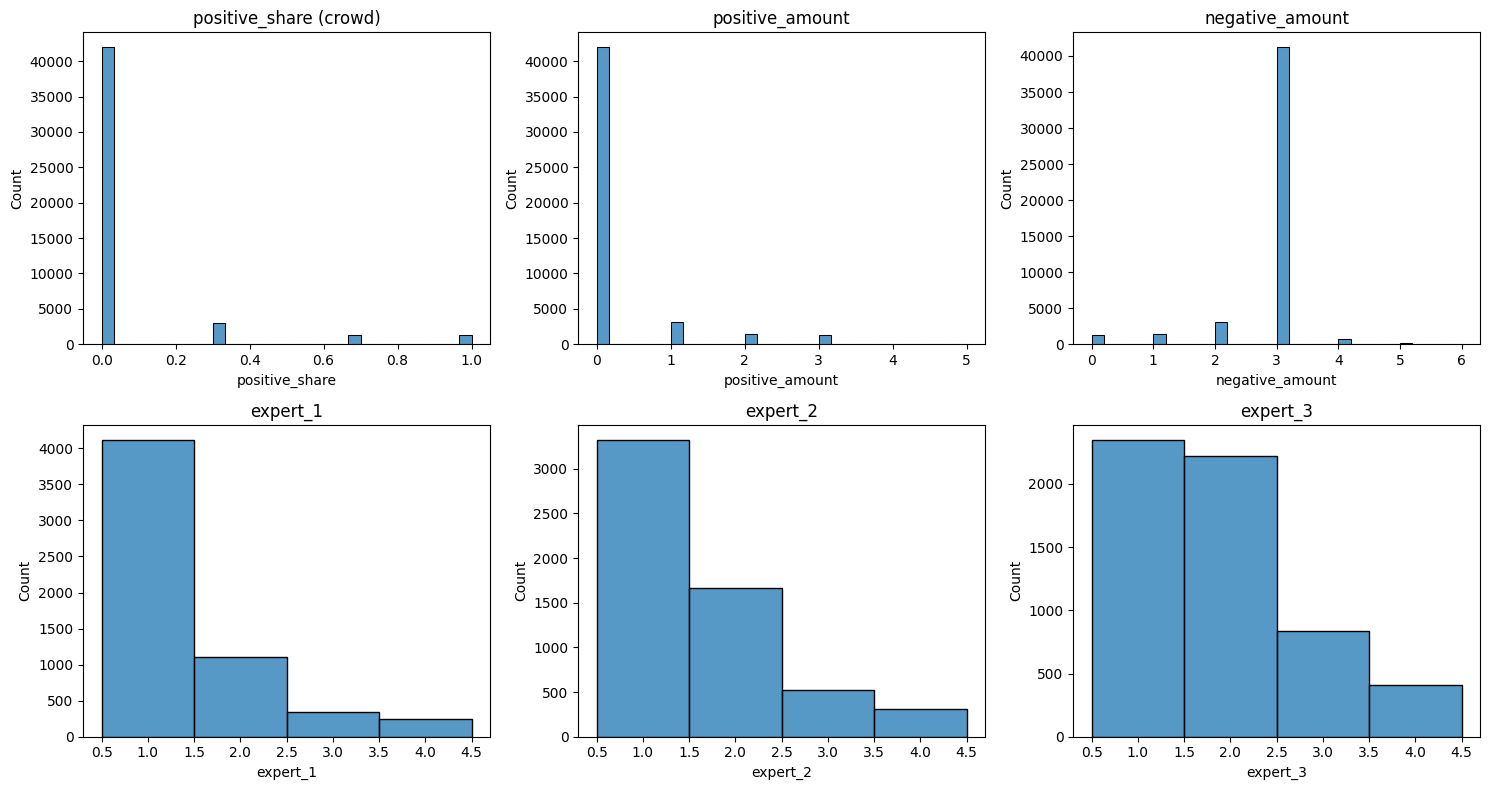

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Crowd
sns.histplot(crowd['positive_share'], bins=30, ax=axes[0,0])
axes[0,0].set_title('positive_share (crowd)')
sns.histplot(crowd['positive_amount'], bins=30, ax=axes[0,1])
axes[0,1].set_title('positive_amount')
sns.histplot(crowd['negative_amount'], bins=30, ax=axes[0,2])
axes[0,2].set_title('negative_amount')

# Expert
sns.histplot(expert['expert_1'], bins=4, discrete=True, ax=axes[1,0])
axes[1,0].set_title('expert_1')
sns.histplot(expert['expert_2'], bins=4, discrete=True, ax=axes[1,1])
axes[1,1].set_title('expert_2')
sns.histplot(expert['expert_3'], bins=4, discrete=True, ax=axes[1,2])
axes[1,2].set_title('expert_3')

plt.tight_layout()
plt.show()

Агрегация экспертных оценок

In [6]:
# Функция для выбора наиболее частой оценки (если есть консенсус)
def most_frequent(row):
    vals = row[['expert_1', 'expert_2', 'expert_3']].values
    if len(set(vals)) == 3:
        return -1  # нет консенсуса
    counter = Counter(vals)
    return counter.most_common(1)[0][0]

expert['agg_expert'] = expert.apply(most_frequent, axis=1)
print("Распределение агрегированных оценок (до удаления спорных):")
print(expert['agg_expert'].value_counts())

# Удаляем строки без консенсуса
expert = expert[expert['agg_expert'] != -1].copy()
print(f"\nПосле удаления спорных: {expert.shape[0]} записей")

# Преобразуем в вероятность: (оценка-1)/3
expert['expert_prob'] = (expert['agg_expert'] - 1) / 3.0
print("\nПример:")
expert[['image', 'query_id', 'agg_expert', 'expert_prob']].head()

Распределение агрегированных оценок (до удаления спорных):
agg_expert
 1    3327
 2    1566
 3     492
 4     311
-1     126
Name: count, dtype: int64

После удаления спорных: 5696 записей

Пример:


,image,query_id,agg_expert,expert_prob
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,0.00
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,0.00
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,0.00
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,2,0.33
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,0.00


Объединение всех данных и формирование целевой переменной

Размер после слияния: (5822, 11)
Размер после удаления пропусков: (5767, 4)
Распределение вероятностей:


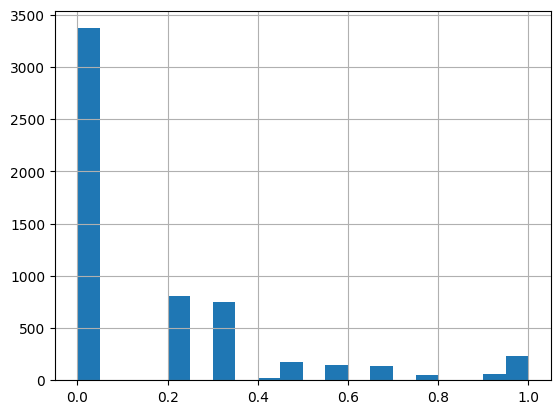

In [7]:
# Объединяем train_df с краудсорсингом и экспертами
train_df = train_df_raw.merge(crowd, how='left', on=['image', 'query_id'])
train_df = train_df.merge(expert, how='left', on=['image', 'query_id'])

print("Размер после слияния:", train_df.shape)

# Функция комбинирования вероятностей (эксперты 0.7, крауд 0.3)
def combine_proba(row):
    crowd_p = row['positive_share']
    expert_p = row['expert_prob']
    if pd.isna(crowd_p) and pd.isna(expert_p):
        return np.nan
    if pd.isna(crowd_p):
        return expert_p
    if pd.isna(expert_p):
        return crowd_p
    return 0.7 * expert_p + 0.3 * crowd_p

train_df['probability'] = train_df.apply(combine_proba, axis=1)

# Оставляем только нужные колонки и удаляем пропуски
train_df = train_df[['image', 'query_id', 'query_text', 'probability']].dropna()
print(f"Размер после удаления пропусков: {train_df.shape}")
print("Распределение вероятностей:")
train_df['probability'].hist(bins=20)
plt.show()

Удаление изображений с детьми (юридические ограничения)

In [8]:
RESTRICT_WORDS = {'child', 'children', 'baby', 'babies', 'boy', 'boys',
                  'girl', 'girls', 'kid', 'kids', 'infant', 'infants',
                  'toddler', 'toddlers'}

def contains_restricted(text):
    words = set(str(text).lower().split())
    return bool(words & RESTRICT_WORDS)

# Находим все запросы с запрещёнными словами
bad_queries = train_df['query_text'].apply(contains_restricted)
bad_images = train_df.loc[bad_queries, 'image'].unique()
print(f"Найдено {len(bad_images)} изображений, связанных с детьми.")

# Удаляем строки с этими изображениями
train_df = train_df[~train_df['image'].isin(bad_images)].reset_index(drop=True)
print(f"Размер после удаления: {train_df.shape}")

Найдено 720 изображений, связанных с детьми.
Размер после удаления: (1457, 4)


Векторизация изображений (ResNet18)

In [9]:
# Инициализация модели ResNet18 для извлечения признаков
weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights=weights)
resnet.to(device)
resnet.eval()

preprocess = weights.transforms(antialias=True)
feature_extractor = create_feature_extractor(resnet, return_nodes={'flatten': 'flatten'})

def get_image_vector(img_path):
    img = read_image(img_path).unsqueeze(0).to(device)
    img = preprocess(img)
    with torch.no_grad():
        features = feature_extractor(img)['flatten'].cpu().numpy().squeeze()
    return features

# Загружаем векторы для всех тренировочных изображений (с кэшированием)
train_image_vectors = {}
cache_file = os.path.join(CACHE_DIR, 'train_image_vectors.pkl')

if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        train_image_vectors = pickle.load(f)
    print(f"Загружено {len(train_image_vectors)} векторов из кэша.")
else:
    print("Создание векторов для тренировочных изображений...")
    for img_name in tqdm(train_df['image'].unique()):
        img_path = os.path.join(TRAIN_IMG_DIR, img_name)
        if os.path.exists(img_path):
            train_image_vectors[img_name] = get_image_vector(img_path)
        else:
            print(f"Предупреждение: файл {img_path} не найден.")
    with open(cache_file, 'wb') as f:
        pickle.dump(train_image_vectors, f)
    print(f"Сохранено {len(train_image_vectors)} векторов.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\DOM/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:13<00:00, 3.59MB/s]


Создание векторов для тренировочных изображений...


  0%|          | 0/280 [00:00<?, ?it/s]

Сохранено 280 векторов.


Векторизация текстов (DistilBERT)

In [10]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = AutoModel.from_pretrained('distilbert-base-uncased').to(device)
bert_model.eval()

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
    sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return sum_embeddings / sum_mask

def text_to_vector(text):
    encoded = tokenizer(text, padding=True, truncation=True, max_length=128,
                        return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = bert_model(**encoded)
    embeddings = mean_pooling(outputs, encoded['attention_mask'])
    return embeddings.cpu().numpy().squeeze()

# Кэшируем векторы текстов (для всех уникальных запросов в train_df)
unique_texts = train_df['query_text'].unique()
text_to_vec = {}
cache_text = os.path.join(CACHE_DIR, 'text_vectors.pkl')

if os.path.exists(cache_text):
    with open(cache_text, 'rb') as f:
        text_to_vec = pickle.load(f)
    print(f"Загружено {len(text_to_vec)} текстовых векторов.")
else:
    print("Создание векторов для текстов...")
    for txt in tqdm(unique_texts):
        text_to_vec[txt] = text_to_vector(txt)
    with open(cache_text, 'wb') as f:
        pickle.dump(text_to_vec, f)
    print(f"Сохранено {len(text_to_vec)} векторов.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Создание векторов для текстов...


  0%|          | 0/556 [00:00<?, ?it/s]

Сохранено 556 векторов.


Формирование объединённых признаков

In [11]:
# Применяем векторы к каждой строке train_df
def get_img_vec(row):
    img_name = row['image']
    if img_name in train_image_vectors:
        return train_image_vectors[img_name]
    else:
        return np.zeros(512)  # если изображение отсутствует (лучше потом отфильтровать)

def get_txt_vec(row):
    txt = row['query_text']
    return text_to_vec.get(txt, np.zeros(768))

train_df['img_vec'] = train_df.apply(get_img_vec, axis=1)
train_df['txt_vec'] = train_df.apply(get_txt_vec, axis=1)

# Объединяем векторы
train_df['combined'] = train_df.apply(lambda r: np.concatenate([r['txt_vec'], r['img_vec']]), axis=1)

# Удаляем строки, где векторы нулевые (если изображение не нашлось)
train_df = train_df[train_df['img_vec'].apply(lambda x: np.any(x != 0))].reset_index(drop=True)
print(f"Размер после фильтрации отсутствующих изображений: {train_df.shape}")

Размер после фильтрации отсутствующих изображений: (1457, 7)


Разделение на train/valid с учётом групп (изображения)

In [12]:
# Подготовка матрицы признаков X и целевой y
X = np.stack(train_df['combined'].values)
y = train_df['probability'].values.reshape(-1, 1)
groups = train_df['image'].values

# GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=RANDOM_STATE)
train_idx, valid_idx = next(gss.split(X, y, groups))

X_train, X_valid = X[train_idx], X[valid_idx]
y_train, y_valid = y[train_idx], y[valid_idx]

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print(f"Train: {X_train_scaled.shape}, Valid: {X_valid_scaled.shape}")

Train: (1047, 1280), Valid: (410, 1280)


Базовое решение – линейная регрессия

In [13]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_valid_scaled)
rmse_lr = np.sqrt(mean_squared_error(y_valid, y_pred_lr))
print(f"Linear Regression RMSE: {rmse_lr:.4f}")

Linear Regression RMSE: 0.5003


Нейросетевая модель

In [14]:
class MatchingNet(nn.Module):
    def __init__(self, input_dim=1280, hidden_dims=[1024, 512, 256], dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MatchingNet().to(device)
print(model)

MatchingNet(
  (net): Sequential(
    (0): Linear(in_features=1280, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


Подготовка DataLoader

In [15]:
class ImageTextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ImageTextDataset(X_train_scaled, y_train)
valid_dataset = ImageTextDataset(X_valid_scaled, y_valid)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

Обучение нейросети

In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_rmse = float('inf')
history = {'train_rmse': [], 'valid_rmse': []}

for epoch in range(1, EPOCHS+1):
    # Train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_rmse = np.sqrt(train_loss / len(train_dataset))

    # Validation
    model.eval()
    valid_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            valid_loss += loss.item() * X_batch.size(0)

    valid_rmse = np.sqrt(valid_loss / len(valid_dataset))

    history['train_rmse'].append(train_rmse)
    history['valid_rmse'].append(valid_rmse)

    print(f"Epoch {epoch:2d}: Train RMSE = {train_rmse:.4f}, Valid RMSE = {valid_rmse:.4f}")

    if valid_rmse < best_rmse:
        best_rmse = valid_rmse
        torch.save(model.state_dict(), os.path.join(CACHE_DIR, 'best_model.pth'))
        print(f"  -> New best model saved (RMSE={best_rmse:.4f})")

Epoch  1: Train RMSE = 0.3129, Valid RMSE = 0.3111
  -> New best model saved (RMSE=0.3111)
Epoch  2: Train RMSE = 0.2653, Valid RMSE = 0.2966
  -> New best model saved (RMSE=0.2966)
Epoch  3: Train RMSE = 0.2460, Valid RMSE = 0.2944
  -> New best model saved (RMSE=0.2944)
Epoch  4: Train RMSE = 0.2297, Valid RMSE = 0.2890
  -> New best model saved (RMSE=0.2890)
Epoch  5: Train RMSE = 0.2104, Valid RMSE = 0.2884
  -> New best model saved (RMSE=0.2884)
Epoch  6: Train RMSE = 0.1857, Valid RMSE = 0.2941
Epoch  7: Train RMSE = 0.1623, Valid RMSE = 0.2945
Epoch  8: Train RMSE = 0.1407, Valid RMSE = 0.3011
Epoch  9: Train RMSE = 0.1309, Valid RMSE = 0.2950
Epoch 10: Train RMSE = 0.1219, Valid RMSE = 0.2968
Epoch 11: Train RMSE = 0.1108, Valid RMSE = 0.2950
Epoch 12: Train RMSE = 0.1063, Valid RMSE = 0.2992
Epoch 13: Train RMSE = 0.0993, Valid RMSE = 0.2987
Epoch 14: Train RMSE = 0.0960, Valid RMSE = 0.3004
Epoch 15: Train RMSE = 0.0916, Valid RMSE = 0.2957
Epoch 16: Train RMSE = 0.0922, Vali

График обучения

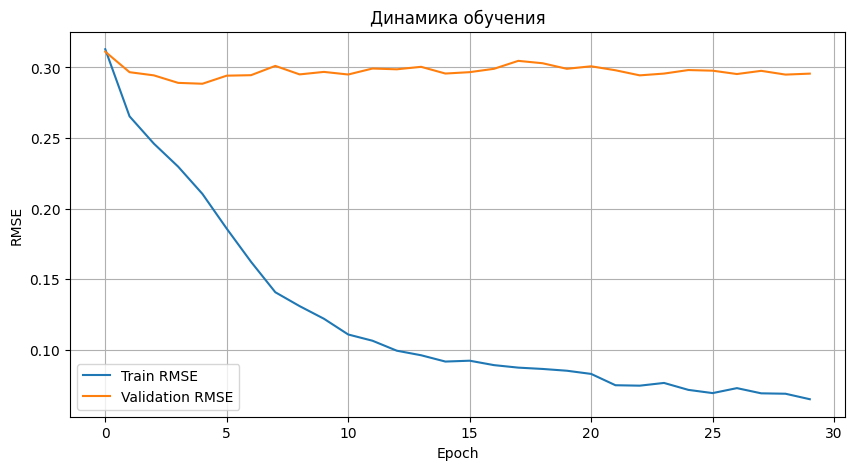

In [17]:
plt.figure(figsize=(10,5))
plt.plot(history['train_rmse'], label='Train RMSE')
plt.plot(history['valid_rmse'], label='Validation RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.title('Динамика обучения')
plt.grid(True)
plt.show()

Загрузка лучшей модели и векторизация тестовых изображений

In [18]:
# Загружаем лучшую модель
model.load_state_dict(torch.load(os.path.join(CACHE_DIR, 'best_model.pth')))
model.eval()

# Векторизация тестовых изображений
test_image_vectors = {}
cache_test = os.path.join(CACHE_DIR, 'test_image_vectors.pkl')

if os.path.exists(cache_test):
    with open(cache_test, 'rb') as f:
        test_image_vectors = pickle.load(f)
    print(f"Загружено {len(test_image_vectors)} тестовых векторов.")
else:
    print("Создание векторов для тестовых изображений...")
    for img_path in tqdm(Path(TEST_IMG_DIR).glob('*.jpg')):
        img_name = img_path.name
        test_image_vectors[img_name] = get_image_vector(str(img_path))
    with open(cache_test, 'wb') as f:
        pickle.dump(test_image_vectors, f)
    print(f"Сохранено {len(test_image_vectors)} векторов.")

Создание векторов для тестовых изображений...


0it [00:00, ?it/s]

Сохранено 100 векторов.


Загрузка тестовых запросов

In [19]:
test_queries = pd.read_csv(test_queries_csv, sep='|')
print(test_queries.shape)
test_queries.head()

(500, 4)


,Unnamed: 0,query_id,query_text,image
0,0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt and the other in blue , are having a water fight .",1177994172_10d143cb8d.jpg
1,1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at each other .,1177994172_10d143cb8d.jpg
4,4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each other .,1177994172_10d143cb8d.jpg


Функция поиска по одному запросу

In [20]:
# Скачиваем изображение-заглушку для запрещённых запросов
no_image_path = os.path.join(CACHE_DIR, 'no_image.jpg')
if not os.path.exists(no_image_path):
    url = 'https://avatars.mds.yandex.net/i?id=b6d682087eb2223c2508aa78975e19c98ac7b554-9182309-images-thumbs&n=13'
    urllib.request.urlretrieve(url, no_image_path)

def search(query_text):
    # Проверка на запрещённые слова
    if contains_restricted(query_text):
        return no_image_path, query_text, None

    # Вектор текста
    text_vec = text_to_vector(query_text)

    # Формируем данные для всех тестовых изображений
    X_list = []
    img_names = []
    for img_name, img_vec in test_image_vectors.items():
        combined = np.concatenate([text_vec, img_vec])
        X_list.append(combined)
        img_names.append(img_name)

    X = np.stack(X_list)
    X_scaled = scaler.transform(X)   # используем тот же scaler

    # Предсказание
    with torch.no_grad():
        preds = model(torch.FloatTensor(X_scaled).to(device)).cpu().numpy().flatten()

    best_idx = np.argmax(preds)
    best_img = img_names[best_idx]
    best_score = preds[best_idx]

    best_path = os.path.join(TEST_IMG_DIR, best_img)
    return best_path, query_text, best_score

Демонстрация на 10 случайных запросах

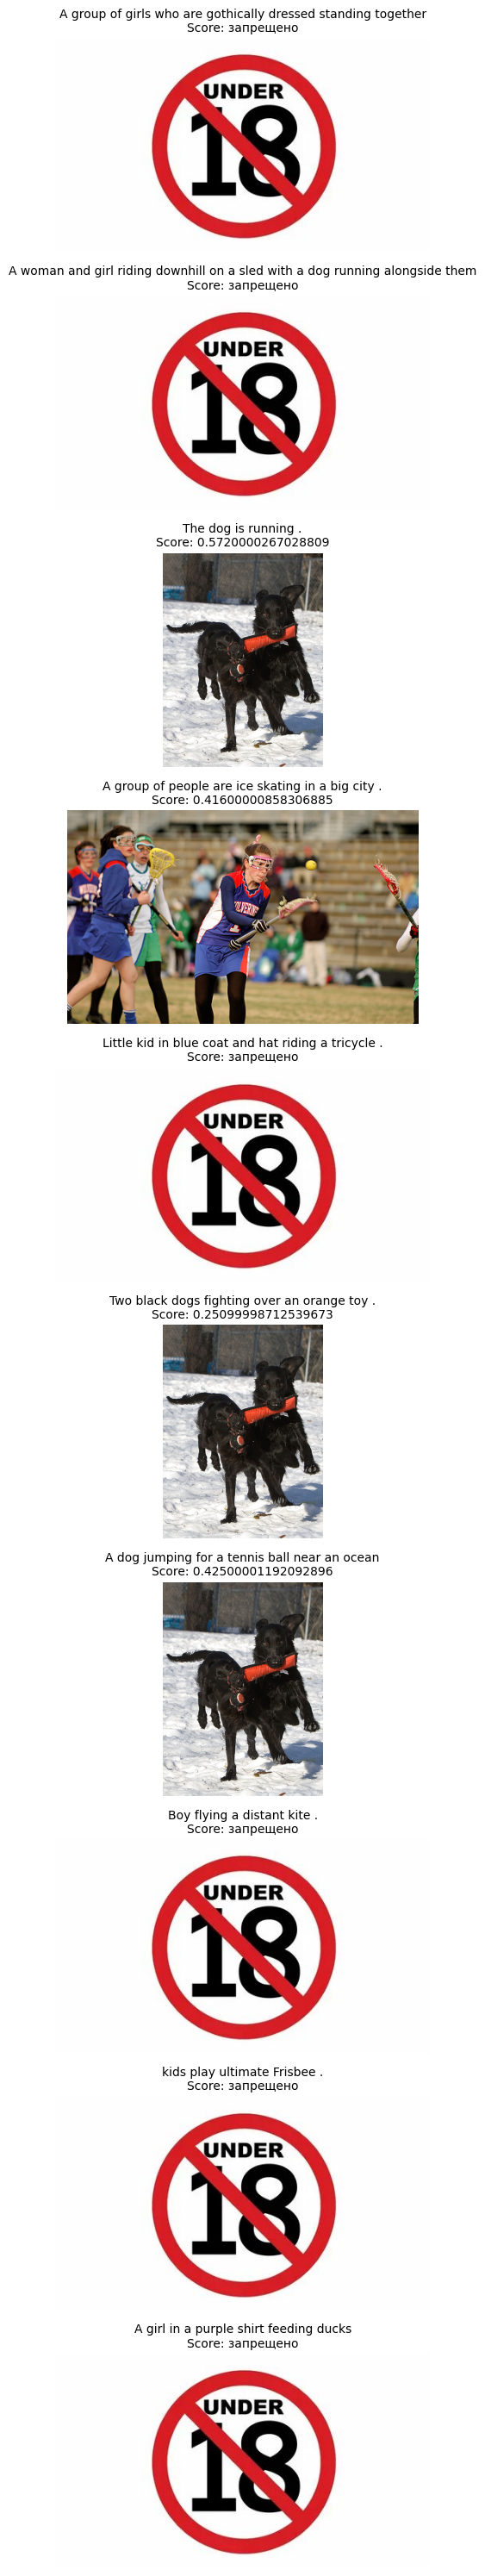

In [21]:
sample_queries = test_queries.sample(MAX_SAMPLE, random_state=RANDOM_STATE)['query_text'].tolist()

images_to_show = []
titles = []
scores = []

for q in sample_queries:
    img_path, title, score = search(q)
    images_to_show.append(img_path)
    titles.append(title)
    scores.append(round(score, 3) if score is not None else "запрещено")

# Отображение
fig, axes = plt.subplots(len(images_to_show), 1, figsize=(10, 3*len(images_to_show)))
if len(images_to_show) == 1:
    axes = [axes]

for ax, img_path, title, score in zip(axes, images_to_show, titles, scores):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{title}\nScore: {score}", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

Сохранение результатов предсказаний для всех тестовых запросов

In [22]:
# Если нужно сохранить предсказания для всех запросов (может занять время)
all_preds = []
for idx, row in tqdm(test_queries.iterrows(), total=len(test_queries)):
    q = row['query_text']
    if contains_restricted(q):
        pred = None
    else:
        text_vec = text_to_vector(q)
        X_list = []
        for img_vec in test_image_vectors.values():
            X_list.append(np.concatenate([text_vec, img_vec]))
        X = np.stack(X_list)
        X_scaled = scaler.transform(X)
        with torch.no_grad():
            preds = model(torch.FloatTensor(X_scaled).to(device)).cpu().numpy().flatten()
        pred = preds.max()
    all_preds.append(pred)

test_queries['predicted_prob'] = all_preds
test_queries.to_csv(os.path.join(CACHE_DIR, 'test_predictions.csv'), index=False)
print("Предсказания сохранены.")

  0%|          | 0/500 [00:00<?, ?it/s]

Предсказания сохранены.


Заключение